In [2]:
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Setup successful!")

Setup successful!


In [4]:
path = kagglehub.dataset_download("adhurimquku/ford-car-price-prediction")

print("Dataset path:", path)

100%|██████████| 174k/174k [00:00<00:00, 253kB/s]

Extracting files...
Dataset path: C:\Users\Lenovo\.cache\kagglehub\datasets\adhurimquku\ford-car-price-prediction\versions\1


In [5]:
import os
import shutil
import kagglehub

# Download dataset
path = kagglehub.dataset_download("adhurimquku/ford-car-price-prediction")

# Get current notebook/project folder
current_folder = os.getcwd()

# Copy all dataset files into current folder
for file in os.listdir(path):
    src = os.path.join(path, file)
    dst = os.path.join(current_folder, file)

    if os.path.isfile(src):
        shutil.copy2(src, dst)

print("Dataset copied to:", current_folder)
print("Files:", os.listdir(current_folder))

Dataset copied to: d:\college\own\ml\scs\week1\day4
Files: ['ford.csv', 'ford_car_ml_analysis.ipynb', 'insurance.csv', 'linear-reg-model.ipynb']


In [6]:
import shutil

cache_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\adhurimquku\ford-car-price-prediction"

shutil.rmtree(cache_path)

print("Kaggle cache deleted.")

Kaggle cache deleted.


In [7]:


df = pd.read_csv("ford.csv")

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [8]:
df.shape

(17966, 9)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [10]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [11]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [12]:
# eda

<Axes: xlabel='price', ylabel='Count'>

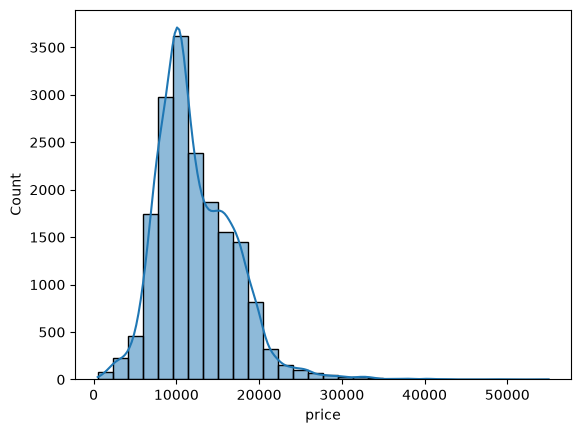

In [13]:
sns.histplot(df['price'], bins=30, kde=True)

<Axes: >

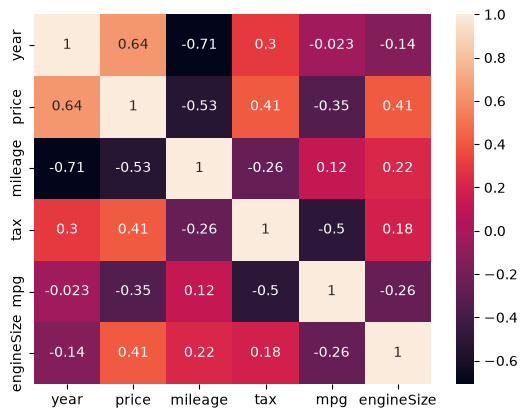

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

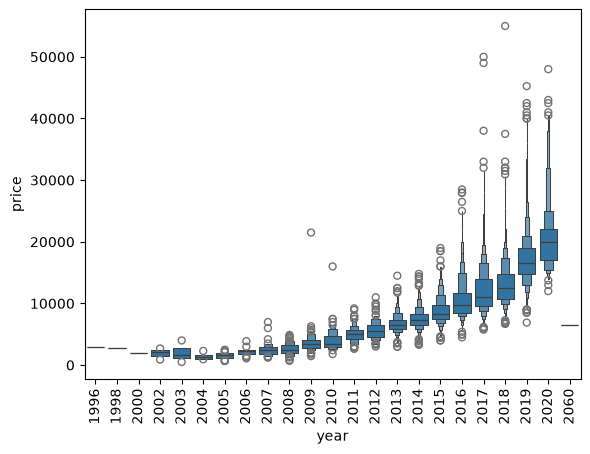

In [17]:
sns.boxenplot(x='year', y='price', data=df)
xticks = plt.xticks(rotation=90)

<Axes: xlabel='mileage', ylabel='price'>

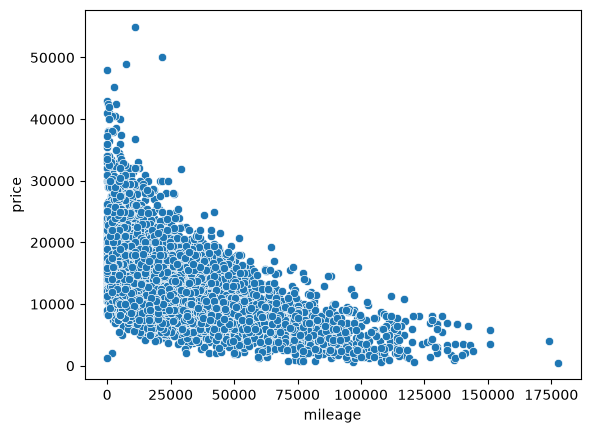

In [18]:
sns.scatterplot(x='mileage', y='price', data=df)

<Axes: xlabel='engineSize', ylabel='price'>

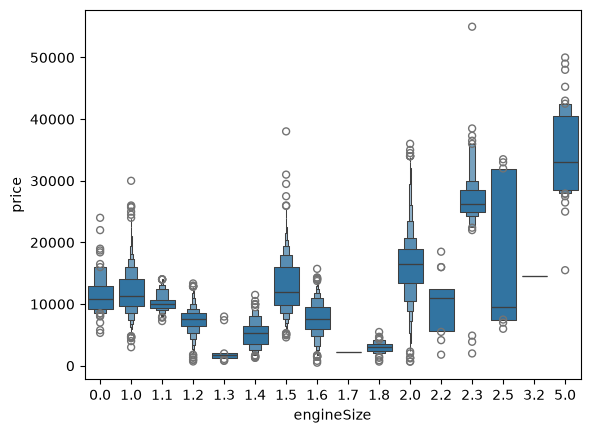

In [19]:
sns.boxenplot(x='engineSize', y='price', data=df)

<Axes: xlabel='transmission', ylabel='price'>

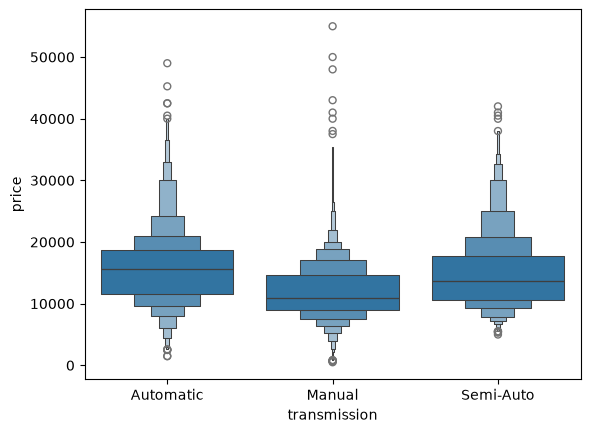

In [20]:
sns.boxenplot(x='transmission', y='price', data=df)

<Axes: xlabel='fuelType', ylabel='price'>

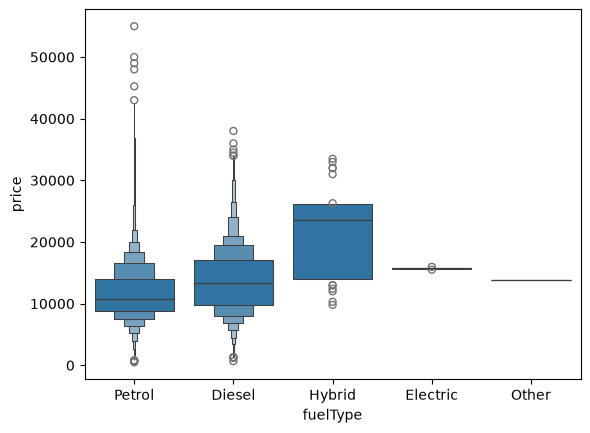

In [21]:
sns.boxenplot(x='fuelType', y='price', data=df)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

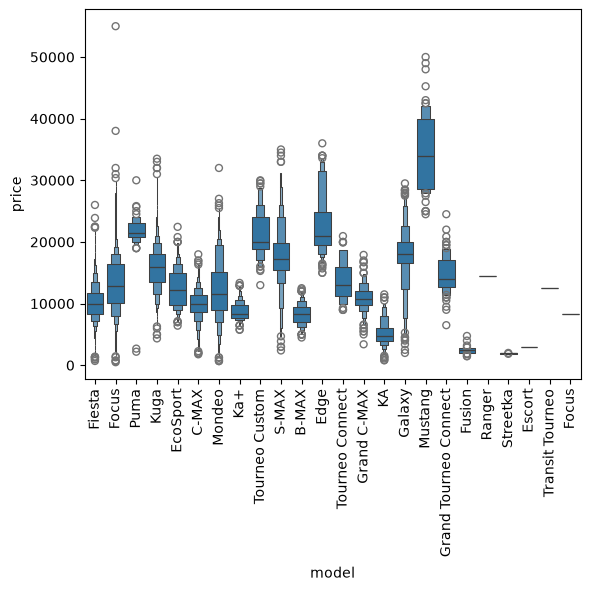

In [22]:
sns.boxenplot(x='model', y='price', data=df)
plt.xticks(rotation=90)

<Axes: xlabel='tax', ylabel='price'>

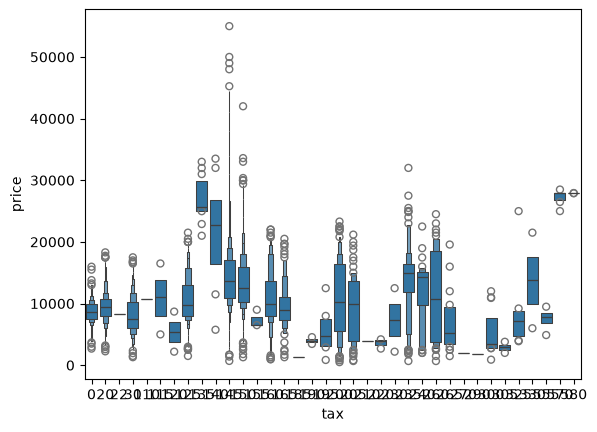

In [24]:
sns.boxenplot(x='tax', y='price', data=df)

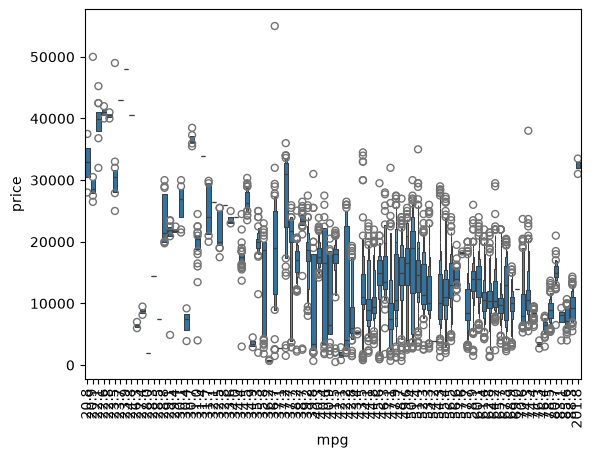

In [31]:
sns.boxenplot(x='mpg', y='price', data=df)
tuck= plt.xticks(rotation=90)

In [32]:
X=df.drop('price', axis=1)
Y=df['price']